In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Utilities import extractor
import uproot
import awkward as ak    

x_MH125=extractor("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH125_LH_2017.root", "Events")


file=uproot.open("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH125_LH_2017.root")
tree=file["Events"]
booleans= tree.arrays(["FatJet_isMatchedWithA"], library="ak")
booleanas=tree.arrays(["FatJet_isMatchedWith2BHadrons"], library="ak")
Fatjet_isMatchedWithA= booleans["FatJet_isMatchedWithA"]
Fatjet_isMatchedWith2BHadrons= booleanas["FatJet_isMatchedWith2BHadrons"]
#Filtriamo i dati

mask = (ak.flatten(Fatjet_isMatchedWithA) == 1) & (ak.flatten(Fatjet_isMatchedWith2BHadrons) == 1)
x_filtered = x_MH125[mask]


/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/riccardo/anaconda3/envs/rootnev/include/site/python3.14); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "
/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


In [2]:
from scipy.special import voigt_profile
from iminuit import Minuit
from iminuit.cost import LeastSquares

x_plot=list(x_filtered)
x_plot.sort()
x_easy=[x for x in x_plot if 75 < x < 175]

def voigt(x, norm, mu, sigma, gamma):
    return voigt_profile(x-mu, sigma, gamma) * norm

bin_counts, bin_edges = np.histogram(x_easy, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_easy) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_easy) * bin_width) # Errore standard per i dati binned

ls_voigt=LeastSquares(bin_centers, bin_densities, yerr, model=voigt)

m_voigt=Minuit(ls_voigt,  norm=1, mu=125, sigma=5, gamma=1)
m_voigt.limits["mu"]= (100, 150)
m_voigt.limits["sigma"]= (0.1, 20)
m_voigt.limits["gamma"]= (0.01, 10)
m_voigt.migrad()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 604.1 (χ²/ndof = 13.1)     │              Nfcn = 132              │
│ EDM = 1.24e-06 (Goal: 0.0002)    │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ norm  │   1.054   │   0.005   │            │            │         │         │       │
│ 1 │ mu    │  126.61   │   0.06    │            │            │   100   │   150   │       │
│ 2 │ sigma │   8.41    │   0.13    │            │            │   0.1   │   20    │       │
│ 3 │ gamma │   4.83    │   0.11    │            │            │  0.01   │   10    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────┐
│       │      norm        mu     sigma     gamma │
├───────┼─────────────────────────────────────────┤
│  norm │  2.58e-05  0.004e-3 -0.171e-3  0.183e-3 │
│    mu │  0.004e-3   0.00387    -0.001     0.000 │
│ sigma │ -0.171e-3    -0.001    0.0167    -0.012 │
│ gamma │  0.183e-3     0.000    -0.012    0.0129 │
└───────┴─────────────────────────────────────────┘

In [3]:
fit_MH125_values={}
fit_MH125_errors={}

fit_values={'MH125': fit_MH125_values,}
fit_errors={'MH125_errors': fit_MH125_errors}

for param in m_voigt.parameters:
    fit_MH125_values[param] = m_voigt.values[param]

for error in m_voigt.parameters:    #Qui non ho capito come fa a capire che deveestarre gli errori 
    fit_MH125_errors[error] = m_voigt.errors[error]

print(fit_MH125_values)
print(fit_MH125_errors)

import json
#QUi sono andato di metodo oragutang, ho deciso di voler fare 2 file separati peer errori e valori 
#Ho tenuto lo stesso quello con tutti i valori, casomai cambiassi idea

with open("fit_results.json", "r") as f:
    results=json.load(f)

with open("fit_values.json", "r") as g:
    values=json.load(g) 

with open("fit_errors.json", "r") as h:
    errors=json.load(h)


results["MH125"]=fit_MH125_values
results["MH125_errors"]=fit_MH125_errors

with open("fit_results.json", "w") as f:
    json.dump(results, f, indent=1)

values["MH125"]=fit_MH125_values
with open("fit_values.json", "w") as g:
    json.dump(values, g, indent=1)  

errors["MH125_errors"]=fit_MH125_errors
with open("fit_errors.json", "w") as h:
    json.dump(errors, h, indent=1)  


{'norm': 1.0543358878617586, 'mu': 126.61423390900535, 'sigma': 8.409705373923497, 'gamma': 4.829092739712042}
{'norm': 0.005081234514561848, 'mu': 0.06222859749561849, 'sigma': 0.12905919355924222, 'gamma': 0.11368323021141169}


<ValueView mu=127.51356096442191 sigma=11.288903099502233 beta=1.061634114277002 m=14.184111523540274>
chi2/ndof =  17.745081033483405
chi2 816.2737275402366


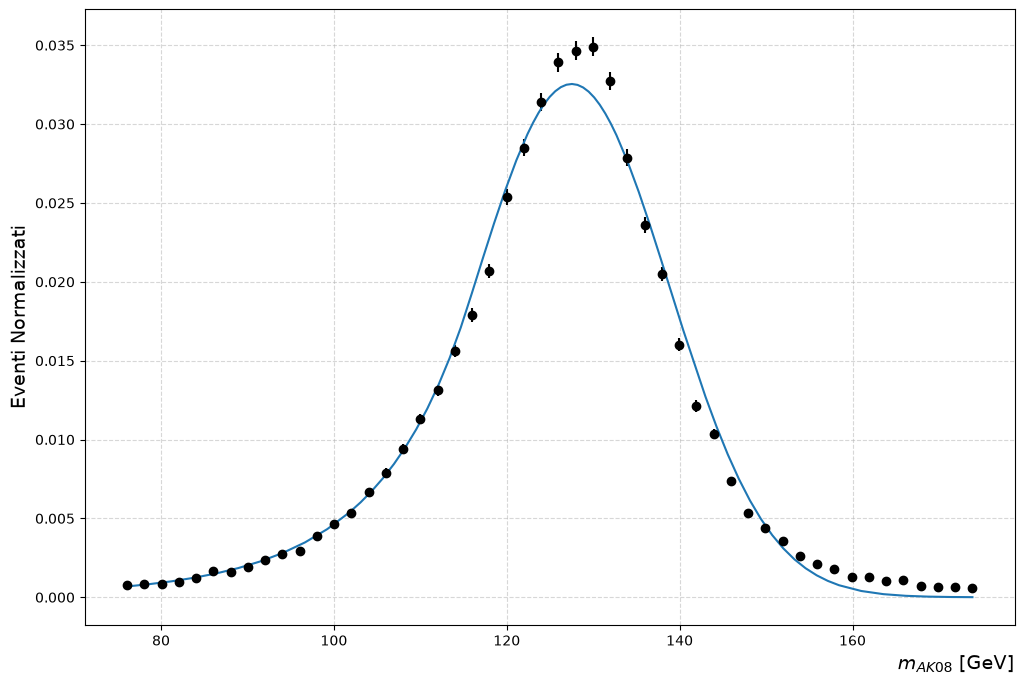

In [4]:
from Utilities import cb_pdf

x_CB=x_easy
y_CB=[cb_pdf(xi, mu=125, sigma=10, beta=1.5, m=30 ) for xi in x_CB]

ls_CB=LeastSquares(bin_centers, bin_densities, yerr, model=cb_pdf)
m=Minuit(ls_CB, mu=125, sigma=10, beta=1.5, m=30)
m.limits["mu"]= (100, 150)
m.limits["sigma"]= (0.1, 20)
m.limits["beta"]= (0.1, 10)
m.limits["m"]= (0.1, 100)
m.migrad()  



ix, ax= plt.subplots(figsize=(12, 8))

m.visualize()
#plt.legend(loc= "upper right", fontsize=14, frameon=True, framealpha=0.9, title="Fit ottimizzato con Minuit")
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
#ax.set_xlim(0, 100)
ax.grid(True, linestyle='--', alpha=0.5)

#plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/CrystallBall_Minuit_25', bbox_inches='tight')
#stampiamo chi2 e chi2 ridotto
print(m.values)
print("chi2/ndof = ", m.fval / m.ndof)
print("chi2", m.fval)

<ValueView mu=126.32667871660229 sigma=12.857735444832205>
chi2/ndof =  52.15921405390639
chi2 2503.6422745875066


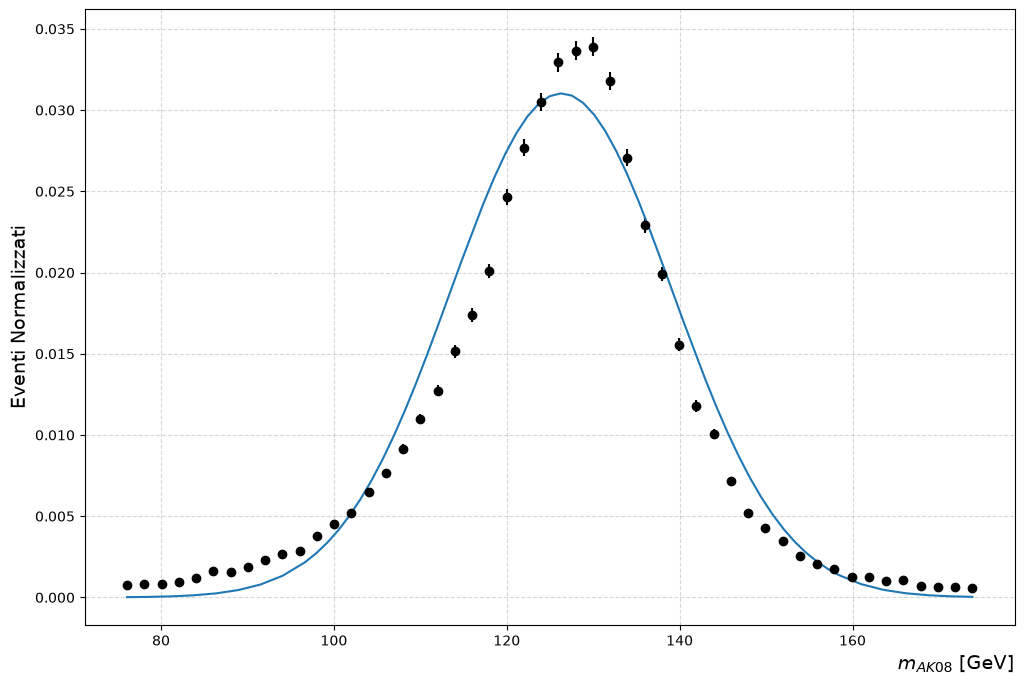

In [5]:
from numba_stats import truncnorm

def gaussiana(x, mu, sigma):
    return truncnorm.pdf(x, *x_range, loc=mu, scale=sigma)

x_gauss=x_easy
x_range=(0, max(x_gauss))

bin_counts, bin_edges = np.histogram(x_easy, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_plot) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_plot) * bin_width) # Errore standard per i dati binned

ls_gauss=LeastSquares(bin_centers, bin_densities, yerr, model=gaussiana)
m_gauss=Minuit(ls_gauss, mu=125, sigma=10)
m_gauss.limits["mu"]= (100, 150)
m_gauss.limits["sigma"]= (0.1, 20)
m_gauss.migrad()

ix, ax= plt.subplots(figsize=(12, 8))



m_gauss.visualize()
#plt.legend(loc= "upper right", fontsize=14, frameon=True, framealpha=0.9, title="Fit ottimizzato con Minuit")
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)

ax.grid(True, linestyle='--', alpha=0.5)
#plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Gauss_Minuit_25', bbox_inches='tight')
#Stampiano chi2 e chi2 ridotto
print(m_gauss.values)
print("chi2/ndof = ", m_gauss.fval / m_gauss.ndof)
print("chi2", m_gauss.fval)
